## Waist mechanism Dynamics

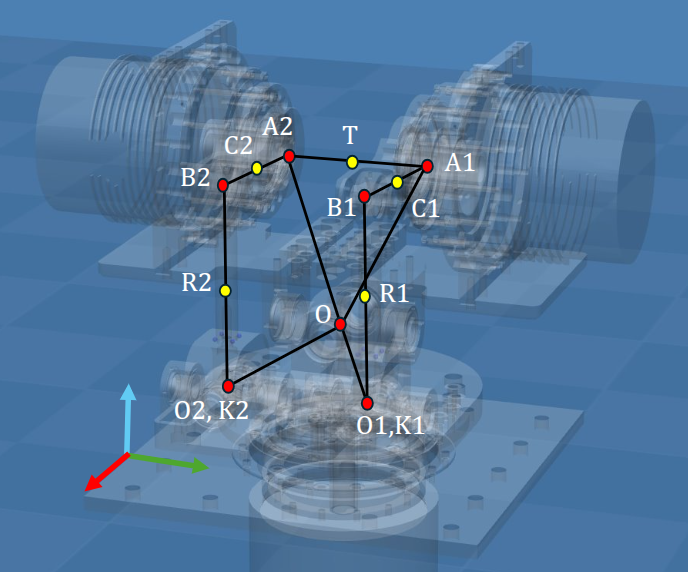

In [ ]:
import sympy as sp
import numpy as np
import sympy.physics.mechanics as me 
me.init_vprinting()

## Frames, Points, coordinates

In [2]:
N, B, U1, U2, L1, L2 = sp.symbols('N, B, U_1, U_2, L_1, L_2', cls=me.ReferenceFrame)
O, T, C1, C2, R1, R2 = sp.symbols('O, T, C_1, C_2, R_1, R_2', cls=me.Point)                                 # CoM points for the bodies
A1, A2, B1, B2, K1, K2, O1, O2 = sp.symbols('A_1, A_2, B_1, B_2, K_1, K_2, O_1, O_2', cls=me.Point)         # points for constraints / loop closure
alpha, beta = me.dynamicsymbols('alpha beta', real="True")
theta1, theta2 = me.dynamicsymbols('theta1:3', real="True")
psi1, psi2 = me.dynamicsymbols('psi1:3', real="True")
phi1, phi2 = me.dynamicsymbols('phi1:3', real="True")

ls, lc, lr, lf = sp.symbols('l_s, l_c, l_r, l_f' , positive="True", real="True")
m_t, m_c, m_r, g = sp.symbols('m_t, m_c, m_r, g', real="True", positive="True")
I_B_Bo = me.inertia(B, 1, 1, 1)
I_U1_U1o = me.inertia(U1, 1, 1, 1)
I_L1_L1o = me.inertia(L1, 1, 1, 1)
I_U2_U2o = me.inertia(U2, 1, 1, 1)
I_L2_L2o = me.inertia(L2, 1, 1, 1)
t = me.dynamicsymbols._t

T1, T2, T3, T4, T5 = me.dynamicsymbols('T1 T_joint18 T3 T_joint19 T5')


In [3]:

u1, u2, u3, u4, u5, u6, u7, u8 = me.dynamicsymbols('u1:9')
q = sp.Matrix([theta1, theta2])
q_r = sp.Matrix([alpha, beta, psi1, psi2, phi1, phi2])
q_N = q.col_join(q_r)
u = sp.Matrix([u1, u2])
u_r = sp.Matrix([u3, u4, u5, u6, u7, u8])
u_N = u.col_join(u_r)

qdot_N = q_N.diff(t)
qddot_N = qdot_N.diff(t)
udot_N = u_N.diff(t)

q_N_zero = {q:0 for q in q_N}
u_r_zero = {u: 0 for u in u_r}
u_N_zero = {u: 0 for u in u_N}
qdot_N_zero = {qd: 0 for qd in qdot_N}
udot_N_zero = {ud: 0 for ud in udot_N}

q, q_r, q_N, u, u_r, u_N, qdot_N, qddot_N, udot_N

⎛            ⎡θ₁⎤              ⎡u₁⎤  ⎡θ₁̇⎤  ⎡θ₁̈⎤  ⎡u₁̇⎤⎞
⎜            ⎢  ⎥              ⎢  ⎥  ⎢  ⎥  ⎢  ⎥  ⎢  ⎥⎟
⎜      ⎡α ⎤  ⎢θ₂⎥        ⎡u₃⎤  ⎢u₂⎥  ⎢θ₂̇⎥  ⎢θ₂̈⎥  ⎢u₂̇⎥⎟
⎜      ⎢  ⎥  ⎢  ⎥        ⎢  ⎥  ⎢  ⎥  ⎢  ⎥  ⎢  ⎥  ⎢  ⎥⎟
⎜      ⎢β ⎥  ⎢α ⎥        ⎢u₄⎥  ⎢u₃⎥  ⎢α̇ ⎥  ⎢α̈ ⎥  ⎢u₃̇⎥⎟
⎜      ⎢  ⎥  ⎢  ⎥        ⎢  ⎥  ⎢  ⎥  ⎢  ⎥  ⎢  ⎥  ⎢  ⎥⎟
⎜⎡θ₁⎤  ⎢ψ₁⎥  ⎢β ⎥  ⎡u₁⎤  ⎢u₅⎥  ⎢u₄⎥  ⎢β̇ ⎥  ⎢β̈ ⎥  ⎢u₄̇⎥⎟
⎜⎢  ⎥, ⎢  ⎥, ⎢  ⎥, ⎢  ⎥, ⎢  ⎥, ⎢  ⎥, ⎢  ⎥, ⎢  ⎥, ⎢  ⎥⎟
⎜⎣θ₂⎦  ⎢ψ₂⎥  ⎢ψ₁⎥  ⎣u₂⎦  ⎢u₆⎥  ⎢u₅⎥  ⎢ψ₁̇⎥  ⎢ψ₁̈⎥  ⎢u₅̇⎥⎟
⎜      ⎢  ⎥  ⎢  ⎥        ⎢  ⎥  ⎢  ⎥  ⎢  ⎥  ⎢  ⎥  ⎢  ⎥⎟
⎜      ⎢φ₁⎥  ⎢ψ₂⎥        ⎢u₇⎥  ⎢u₆⎥  ⎢ψ₂̇⎥  ⎢ψ₂̈⎥  ⎢u₆̇⎥⎟
⎜      ⎢  ⎥  ⎢  ⎥        ⎢  ⎥  ⎢  ⎥  ⎢  ⎥  ⎢  ⎥  ⎢  ⎥⎟
⎜      ⎣φ₂⎦  ⎢φ₁⎥        ⎣u₈⎦  ⎢u₇⎥  ⎢φ₁̇⎥  ⎢φ₁̈⎥  ⎢u₇̇⎥⎟
⎜            ⎢  ⎥              ⎢  ⎥  ⎢  ⎥  ⎢  ⎥  ⎢  ⎥⎟
⎝            ⎣φ₂⎦              ⎣u₈⎦  ⎣φ₂̇⎦  ⎣φ₂̈⎦  ⎣u₈̇⎦⎠

## Framing and coordinates setting

In [4]:
B.orient_space_fixed(N, (alpha, beta, 0),'XYZ')
U1.orient_axis(B, B.y, theta1)
L1.orient_space_fixed(U1, (psi1, psi2, 0), 'XYZ')

U2.orient_axis(B, B.y, theta2)
L2.orient_space_fixed(U2, (phi1, phi2, 0), 'XYZ')

O1.set_pos(O, lc*N.x + ls/2*N.y - lf*N.z)
O2.set_pos(O, lc*N.x - ls/2*N.y - lf*N.z)

T.set_pos(O, (lr - lf)*B.z)

A1.set_pos(T, ls/2*B.y)
C1.set_pos(A1, lc/2*U1.x)
B1.set_pos(C1, lc/2*U1.x)
R1.set_pos(B1,- lr/2*L1.z)
K1.set_pos(R1,- lr/2*L1.z)

A2.set_pos(T,- ls/2*B.y)
C2.set_pos(A2, lc/2*U2.x)
B2.set_pos(C2, lc/2*U2.x)
R2.set_pos(B2,- lr/2*L2.z)
K2.set_pos(R2,- lr/2*L2.z)


In [5]:
# position check

K1.pos_from(O).express(N).xreplace(q_N_zero)

In [6]:
# loop closure equations

loop_closure1 = K1.pos_from(O) - O1.pos_from(O)
loop_closure2 = K2.pos_from(O) - O2.pos_from(O)
rod_constraint1 = B1.pos_from(O) - O1.pos_from(O)
rod_constraint2 = B2.pos_from(O) - O2.pos_from(O)


## Algebraic Holonomic constraint equations

In [7]:
# Holonomic constraints

fh = sp.Matrix([
    loop_closure1.dot(N.y) - 0,
    loop_closure2.dot(N.y) - 0,
    loop_closure1.dot(N.z) - 0,
    loop_closure2.dot(N.z) - 0,
    rod_constraint1.dot(rod_constraint1) - lr**2,
    rod_constraint2.dot(rod_constraint2) - lr**2,
    # loop_closure1.dot(N.x) - 0,
    # loop_closure2.dot(N.x) - 0,
    ])

fh = fh.applyfunc(lambda i: sp.simplify(sp.trigsimp(i)))



In [8]:
# fh

#### Constraint equation dependencies

In [9]:
me.find_dynamicsymbols(fh[0]), me.find_dynamicsymbols(fh[1]),


In [10]:
me.find_dynamicsymbols(fh[2]), me.find_dynamicsymbols(fh[3]),
    

In [11]:
me.find_dynamicsymbols(fh[4]), me.find_dynamicsymbols(fh[5])

## Kinematic differential equations

In [12]:
fk = sp.Matrix([
    theta1.diff(t) - u1,
    theta2.diff(t) - u2,
    alpha.diff(t) - u3,
    beta.diff(t) - u4,
    psi1.diff(t) - u5,
    psi2.diff(t) - u6,
    phi1.diff(t) - u7,
    phi2.diff(t) - u8,
])

Mk = fk.jacobian(qdot_N)
gk = fk.xreplace(qdot_N_zero)
qdot_N_sol = -Mk.LUsolve(gk)

qdot_N_replace = dict((zip(qdot_N, qdot_N_sol)))
qdot_N_replace

In [13]:
Mk, qdot_N, gk

⎛⎡1  0  0  0  0  0  0  0⎤  ⎡θ₁̇⎤  ⎡-u₁⎤⎞
⎜⎢                      ⎥  ⎢  ⎥  ⎢   ⎥⎟
⎜⎢0  1  0  0  0  0  0  0⎥  ⎢θ₂̇⎥  ⎢-u₂⎥⎟
⎜⎢                      ⎥  ⎢  ⎥  ⎢   ⎥⎟
⎜⎢0  0  1  0  0  0  0  0⎥  ⎢α̇ ⎥  ⎢-u₃⎥⎟
⎜⎢                      ⎥  ⎢  ⎥  ⎢   ⎥⎟
⎜⎢0  0  0  1  0  0  0  0⎥  ⎢β̇ ⎥  ⎢-u₄⎥⎟
⎜⎢                      ⎥, ⎢  ⎥, ⎢   ⎥⎟
⎜⎢0  0  0  0  1  0  0  0⎥  ⎢ψ₁̇⎥  ⎢-u₅⎥⎟
⎜⎢                      ⎥  ⎢  ⎥  ⎢   ⎥⎟
⎜⎢0  0  0  0  0  1  0  0⎥  ⎢ψ₂̇⎥  ⎢-u₆⎥⎟
⎜⎢                      ⎥  ⎢  ⎥  ⎢   ⎥⎟
⎜⎢0  0  0  0  0  0  1  0⎥  ⎢φ₁̇⎥  ⎢-u₇⎥⎟
⎜⎢                      ⎥  ⎢  ⎥  ⎢   ⎥⎟
⎝⎣0  0  0  0  0  0  0  1⎦  ⎣φ₂̇⎦  ⎣-u₈⎦⎠

In [14]:
sp.Eq(u_r,q_r.diff(t))

⎡u₃⎤   ⎡α̇ ⎤
⎢  ⎥   ⎢  ⎥
⎢u₄⎥   ⎢β̇ ⎥
⎢  ⎥   ⎢  ⎥
⎢u₅⎥   ⎢ψ₁̇⎥
⎢  ⎥ = ⎢  ⎥
⎢u₆⎥   ⎢ψ₂̇⎥
⎢  ⎥   ⎢  ⎥
⎢u₇⎥   ⎢φ₁̇⎥
⎢  ⎥   ⎢  ⎥
⎣u₈⎦   ⎣φ₂̇⎦

In [15]:
fh_d = fh.diff(t).xreplace(qdot_N_replace)

Mh_d = fh_d.jacobian(u_r)
gh_d = fh_d.xreplace(u_r_zero)

me.find_dynamicsymbols(fh.diff(t)), me.find_dynamicsymbols(fh_d), me.find_dynamicsymbols(gh_d)

In [16]:
u_r_sol = -Mh_d.LUsolve(gh_d)
# u_r_sol = sp.trigsimp(u_r_sol.simplify())

u_r_replace = dict(zip(u_r, u_r_sol))

me.find_dynamicsymbols(u_r_sol)

## Linear & Angular velocities

In [22]:
qdot_N_replace = dict((zip(qdot_N, qdot_N_sol)))
qddot_N_replace = dict(zip(qddot_N,udot_N))

w_B_N  = B.ang_vel_in(N).xreplace(qdot_N_replace).xreplace(u_r_replace)
w_U1_N = U1.ang_vel_in(N).xreplace(qdot_N_replace).xreplace(u_r_replace)
w_L1_N = L1.ang_vel_in(N).xreplace(qdot_N_replace).xreplace(u_r_replace)
w_U2_N = U2.ang_vel_in(N).xreplace(qdot_N_replace).xreplace(u_r_replace)
w_L2_N = L2.ang_vel_in(N).xreplace(qdot_N_replace).xreplace(u_r_replace)

wd_B_N  = B.ang_acc_in(N).xreplace(qdot_N_replace).xreplace(qddot_N_replace).xreplace(u_r_replace)
wd_U1_N = U1.ang_acc_in(N).xreplace(qdot_N_replace).xreplace(qddot_N_replace).xreplace(u_r_replace)
wd_L1_N = L1.ang_acc_in(N).xreplace(qdot_N_replace).xreplace(qddot_N_replace).xreplace(u_r_replace)
wd_U2_N = U2.ang_acc_in(N).xreplace(qdot_N_replace).xreplace(qddot_N_replace).xreplace(u_r_replace)
wd_L2_N = L2.ang_acc_in(N).xreplace(qdot_N_replace).xreplace(qddot_N_replace).xreplace(u_r_replace)

In [23]:
me.find_dynamicsymbols(w_B_N, reference_frame=N)

## Linear & angular acceleration

In [24]:
me.find_dynamicsymbols(B.ang_acc_in(N), reference_frame=N)

In [25]:
O.set_vel(N,0)
v_T_N  = T.v2pt_theory(O, N, B).xreplace(qdot_N_replace).xreplace(u_r_replace)
v_C1_N = C1.v2pt_theory(O, N, U1).xreplace(qdot_N_replace).xreplace(u_r_replace)
v_R1_N = R1.v2pt_theory(O, N, L1).xreplace(qdot_N_replace).xreplace(u_r_replace)
v_C2_N = C2.v2pt_theory(O, N, U2).xreplace(qdot_N_replace).xreplace(u_r_replace)
v_R2_N = R2.v2pt_theory(O, N, L2).xreplace(qdot_N_replace).xreplace(u_r_replace)

a_T_N  = T.acc(N).xreplace(qdot_N_replace).xreplace(qddot_N_replace).xreplace(u_r_replace)
a_R1_N = R1.acc(N).xreplace(qdot_N_replace).xreplace(qddot_N_replace).xreplace(u_r_replace)
a_C1_N = C1.acc(N).xreplace(qdot_N_replace).xreplace(qddot_N_replace).xreplace(u_r_replace)
a_C2_N = C2.acc(N).xreplace(qdot_N_replace).xreplace(qddot_N_replace).xreplace(u_r_replace)
a_R2_N = R2.acc(N).xreplace(qdot_N_replace).xreplace(qddot_N_replace).xreplace(u_r_replace)

In [26]:
me.find_dynamicsymbols(wd_B_N, reference_frame=N)

## Generalised Active and Inertial forces

In [27]:
# Forces

R_T  = -m_t*g*N.z
R_C1 = -m_c*g*N.z 
R_R1 = -m_r*g*N.z
R_C2 = -m_c*g*N.z
R_R2 = -m_r*g*N.z

# Torques

T_B = - T2*B.y - T4*B.y
T_U1 = T2*U1.y
T_L1 = me.Vector(0)
T_U2 = T4*U2.y
T_L2 = me.Vector(0)


In [ ]:

ang_vel = [w_B_N, w_U1_N, w_L1_N, w_U2_N, w_L2_N]
lin_vel = [v_T_N, v_C1_N, v_R1_N, v_C2_N, v_R2_N]
 
ang_acc = [wd_B_N, wd_U1_N, wd_L1_N, wd_U2_N, wd_L2_N]
lin_acc = [a_T_N, a_C1_N, a_R1_N, a_C2_N, a_R2_N]

masses = [m_t, m_c, m_r ,m_c, m_r]
forces = [R_T, R_C1, R_R1, R_C2, R_R2]

inertias = [I_B_Bo, I_U1_U1o, I_L1_L1o, I_U2_U2o, I_L2_L2o]
torques = [T_B, T_U1, T_L1, T_U2, T_L2]

Fr_bar = []
Frs_bar = []

for ur in [u1, u2]:

    Fr = 0
    Frs = 0

    for vi, ai, Ri, mi in zip(lin_vel, lin_acc, forces, masses):
        vr = vi.diff(ur, N)
        Fr += vr.dot(Ri)
        Rs = -mi*ai
        Frs += vr.dot(Rs)

    for wi, aai, Ti, Ii in zip(ang_vel, ang_acc, torques, inertias):
        wr = wi.diff(ur, N)
        Fr += wr.dot(Ti)
        Ts = -(aai.dot(Ii) +
               me.cross(wi, Ii).dot(wi))
        Frs += wr.dot(Ts)

    Fr_bar.append(Fr)
    Frs_bar.append(Frs)

Fr = sp.Matrix(Fr_bar)
Frs = sp.Matrix(Frs_bar)

In [ ]:
# me.find_dynamicsymbols(Fr), me.find_dynamicsymbols(Frs)

## Equations of Motion

In [ ]:
EOM = Fr + Frs